In [1]:
import time
import numpy as np, pandas as pd
import keras 
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import platform

# 한글 폰트 설정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [2]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [3]:
train_input.shape

(60000, 28, 28)

In [4]:
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

In [5]:
train_scaled.shape

(60000, 28, 28, 1)


---
## BASIC

In [6]:
basic_model = keras.Sequential(
    [
        keras.layers.Input(shape=(28, 28, 1)),
        keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Flatten(),
        keras.layers.Dense(100, activation="relu"),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(10, activation="softmax"),
    ]
)

In [7]:
basic_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       627,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 628,630 (2.40 MB)

 Trainable params: 628,630 (2.40 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
basic_model.compile(
    optimizer="adam",
    loss=keras.losses.sparse_categorical_crossentropy,
    metrics=["accuracy"],
    jit_compile=False,
)

In [9]:
checkpoint = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True)
early_stopping = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

In [10]:
start = time.time()

history = basic_model.fit(
    train_scaled, train_target,
    callbacks=[checkpoint, early_stopping],
    epochs=20, validation_split=0.2
)


end = time.time()
basic_time = end - start

print("BASIC 학습 시간:", round(basic_time, 2), "초")

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8249 - loss: 0.5000 - val_accuracy: 0.8837 - val_loss: 0.3191
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8799 - loss: 0.3379 - val_accuracy: 0.8982 - val_loss: 0.2827
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8917 - loss: 0.2978 - val_accuracy: 0.9021 - val_loss: 0.2680
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8997 - loss: 0.2712 - val_accuracy: 0.9087 - val_loss: 0.2617
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9099 - loss: 0.2495 - val_accuracy: 0.9116 - val_loss: 0.2479
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9156 - loss: 0.2301 - val_accuracy: 0.9124 - val_loss: 0.2498
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9207 - loss: 0.2148 - val_accuracy: 0.9109 - val_loss: 0.2477
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9248 - loss: 0.2025 - 

In [11]:
print("최고 val_accuracy:", max(history.history["val_accuracy"]))
print("최종 val_accuracy:", history.history["val_accuracy"][-1])
print("최종 train_accuracy:", history.history["accuracy"][-1])

최고 val_accuracy: 0.9169999957084656
최종 val_accuracy: 0.9138333201408386
최종 train_accuracy: 0.9331874847412109


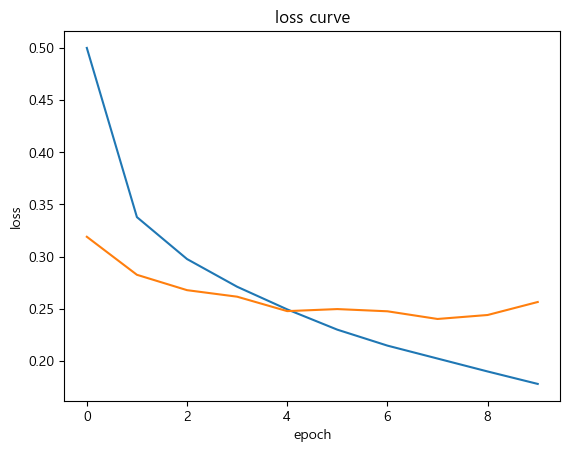

In [12]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("loss curve")
plt.show()

In [13]:
basic_model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9092 - loss: 0.2569


[0.2569475471973419, 0.9092000126838684]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


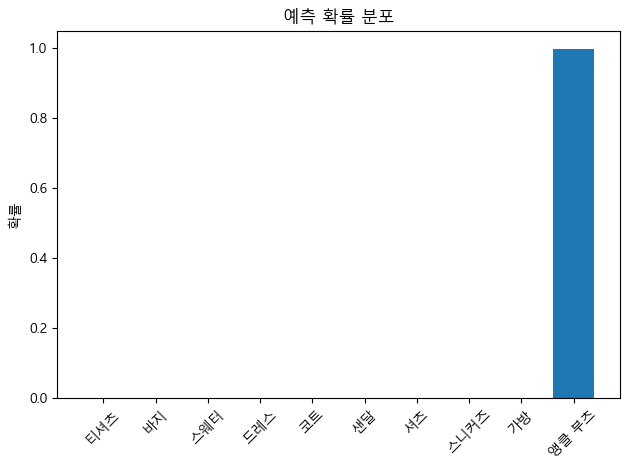

In [14]:
pred = basic_model.predict(test_scaled[0:1])
np.argmax(pred)

classes = ['티셔츠', '바지', '스웨터', '드레스', '코트',
            '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']

classes[np.argmax(pred)]

plt.bar(range(1, 11), pred[0])
plt.xticks(range(1, 11), classes, rotation=45)
plt.ylabel("확률")
plt.title("예측 확률 분포")
plt.tight_layout()
plt.show()

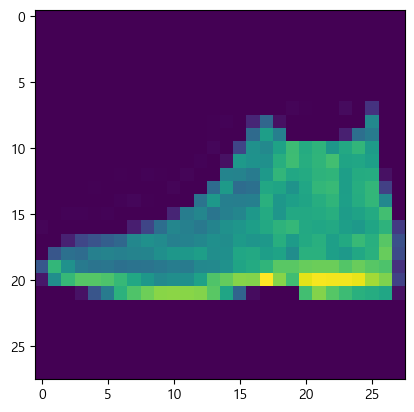

In [15]:
plt.imshow(test_scaled[0])
plt.show()


---
## APPLIED

In [16]:
applied_model = keras.Sequential([
    keras.layers.Input(shape=(28,28,1)),
    # Layer 1
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.MaxPool2D(2),
    # Layer 2
    keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    keras.layers.MaxPool2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(10, activation='softmax')
])


In [17]:
applied_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
applied_model.compile(
    optimizer="adam",
    loss=keras.losses.sparse_categorical_crossentropy,
    metrics=["accuracy"],
    jit_compile=False,
)

In [19]:
checkpoint = keras.callbacks.ModelCheckpoint(
    "applied-best-model.keras", save_best_only=True
)

early_stopping = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

In [20]:
start = time.time()

history_applied = applied_model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_split=0.2,
    callbacks=[checkpoint, early_stopping],
)

end = time.time()
applied_time = end - start

print("APPLIED 학습 시간:", round(applied_time, 2), "초")

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8134 - loss: 0.5258 - val_accuracy: 0.8763 - val_loss: 0.3422
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8744 - loss: 0.3524 - val_accuracy: 0.8966 - val_loss: 0.2879
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8914 - loss: 0.3029 - val_accuracy: 0.8988 - val_loss: 0.2749
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9030 - loss: 0.2662 - val_accuracy: 0.9053 - val_loss: 0.2559
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9095 - loss: 0.2447 - val_accuracy: 0.9069 - val_loss: 0.2477
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9162 - loss: 0.2240 - val_accuracy: 0.9146 - val_loss: 0.2333
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9245 - loss: 0.2081 - val_accuracy: 0.9186 - val_loss: 0.2225
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9288 - loss: 0.1912 - 

In [22]:
applied_model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9121 - loss: 0.2424


[0.24237793684005737, 0.9121000170707703]

In [23]:
print("APPLIED 최고 val_accuracy:", max(history_applied.history["val_accuracy"]))
print("APPLIED 최종 val_accuracy:", history_applied.history["val_accuracy"][-1])
print("APPLIED 최종 train_accuracy:", history_applied.history["accuracy"][-1])

APPLIED 최고 val_accuracy: 0.918583333492279
APPLIED 최종 val_accuracy: 0.9107499718666077
APPLIED 최종 train_accuracy: 0.932645857334137


In [24]:
result_df = pd.DataFrame(
    {
        "모델": ["BASIC", "APPLIED"],
        "구조": ["Conv2D(32)", "Conv2D(32) → Conv2D(64)"],
        "파라미터 수": [basic_model.count_params(), applied_model.count_params()],
        "최고 val_accuracy": [
            round(max(history.history["val_accuracy"]), 4),
            round(max(history_applied.history["val_accuracy"]), 4),
        ],
        "학습 시간(초)": [round(basic_time, 2), round(applied_time, 2)],
    }
)

result_df

,모델,구조,파라미터 수,최고 val_accuracy,학습 시간(초)
0,BASIC,Conv2D(32),628630,0.9170,77.75
1,APPLIED,Conv2D(32) → Conv2D(64),333526,0.9186,68.10
